In [1]:
import numpy as np
from scipy.optimize import minimize

# 1. GENERATE DUMMY DATA
np.random.seed(42)
n = 100
true_tau = 45.0
true_theta1 = 2.0
true_theta2 = 7.0
true_s = 1.0  # Sharp transition

# Generate time steps and smooth true parameters
t = np.arange(1, n + 1)
w_true = 1 / (1 + np.exp(-(t - true_tau) / true_s))
theta_true = (1 - w_true) * true_theta1 + w_true * true_theta2

# Sample Poisson counts
X = np.random.poisson(theta_true)

# 2. DEFINE OBJECTIVE FUNCTION & GRADIENTS
def loss_and_gradient(params, X, t):
    """
    Computes Negative Log-Likelihood and its gradient for a
    smooth single-changepoint Poisson model.
    """
    theta1, theta2, tau, s = params

    # Avoid division by zero or log of negative numbers
    theta1 = max(theta1, 1e-5)
    theta2 = max(theta2, 1e-5)
    s = max(s, 1e-5)

    # Sigmoid weights and effective theta(t)
    w = 1 / (1 + np.exp(-(t - tau) / s))
    theta_t = (1 - w) * theta1 + w * theta2

    # Negative Log-Likelihood (Minimize NLL to Maximize Likelihood)
    nll = -np.sum(X * np.log(theta_t) - theta_t)

    # Common prediction error term
    pred_error = (X / theta_t) - 1.0

    # Gradients with respect to each parameter
    d_theta1 = -np.sum(pred_error * (1 - w))
    d_theta2 = -np.sum(pred_error * w)

    # Derivative of w(t) w.r.t tau and s
    dw_dtau = -(1/s) * w * (1 - w)
    dw_ds = -w * (1 - w) * ((t - tau) / (s**2))

    # Chain rule parts for tau and s via theta(t)
    dtheta_dw = theta2 - theta1

    d_tau = -np.sum(pred_error * dtheta_dw * dw_dtau)
    d_s = -np.sum(pred_error * dtheta_dw * dw_ds)

    grad = np.array([d_theta1, d_theta2, d_tau, d_s])
    return nll, grad

# 3. RUN THE ITERATIVE OPTIMIZATION
# Initial guesses: [theta1, theta2, tau, s]
# Start tau at 50 (midpoint) and s at 2.0 (slightly smoother start)
initial_guess = [np.mean(X[:50]), np.mean(X[50:]), 50.0, 2.0]

# Define bounds to prevent unphysical values (e.g., negative rates or s)
bounds = [(1e-3, None), (1e-3, None), (1, n), (0.1, 10.0)]

print("Optimizing parameters using L-BFGS-B...")
result = minimize(
    fun=loss_and_gradient,
    x0=initial_guess,
    args=(X, t),
    jac=True,  # Tell scipy we are providing the analytical gradient vector
    method='L-BFGS-B',
    bounds=bounds
)

# 4. DISPLAY RESULTS
if result.success:
    est_theta1, est_theta2, est_tau, est_s = result.x
    print("\nOptimization Successful!")
    print(f"{'Parameter':<12} | {'True Value':<10} | {'Estimated MLE':<15}")
    print("-" * 45)
    print(f"{'theta1':<12} | {true_theta1:<10} | {est_theta1:.4f}")
    print(f"{'theta2':<12} | {true_theta2:<10} | {est_theta2:.4f}")
    print(f"{'tau':<12} | {true_tau:<10} | {est_tau:.4f}")
    print(f"{'s':<12} | {true_s:<10} | {est_s:.4f}")
else:
    print("Optimization failed:", result.message)

Optimizing parameters using L-BFGS-B...

Optimization Successful!
Parameter    | True Value | Estimated MLE  
---------------------------------------------
theta1       | 2.0        | 2.0630
theta2       | 7.0        | 7.1640
tau          | 45.0       | 45.8638
s            | 1.0        | 1.4539


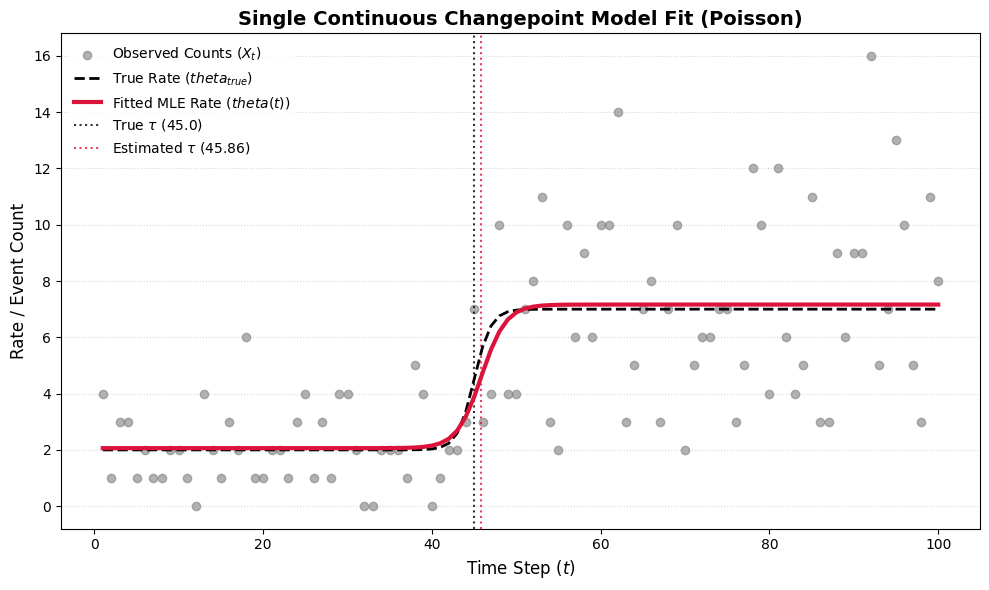

In [5]:
import matplotlib.pyplot as plt

# Ensure you run this code in the same session after running the optimization script above,
# as it relies on the variables (t, X, theta_true, true_tau, result) defined there.

if result.success:
    # Extract optimized parameters
    est_theta1, est_theta2, est_tau, est_s = result.x

    # Compute the fitted MLE parameter curve over time
    w_est = 1 / (1 + np.exp(-(t - est_tau) / est_s))
    theta_est = (1 - w_est) * est_theta1 + w_est * est_theta2

    # Plotting
    plt.figure(figsize=(10, 6))

    # 1. Plot the raw simulated count data
    plt.scatter(t, X, color='gray', alpha=0.6, label='Observed Counts ($X_t$)', zorder=2)

    # 2. Plot the true generative rate
    plt.plot(t, theta_true, color='black', linestyle='--', linewidth=2, label='True Rate ($theta_{true}$)', zorder=3)

    # 3. Plot the fitted MLE rate
    plt.plot(t, theta_est, color='crimson', linewidth=3, label='Fitted MLE Rate ($theta(t)$)', zorder=4)

    # 4. Mark the true vs estimated changepoint locations
    plt.axvline(true_tau, color='black', linestyle=':', alpha=0.8, label=f'True $\\tau$ ({true_tau})')
    plt.axvline(est_tau, color='crimson', linestyle=':', alpha=0.8, label=f'Estimated $\\tau$ ({est_tau:.2f})')

    # Aesthetic adjustments
    plt.title('Single Continuous Changepoint Model Fit (Poisson)', fontsize=14, fontweight='bold')
    plt.xlabel('Time Step ($t$)', fontsize=12)
    plt.ylabel('Rate / Event Count', fontsize=12)
    plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
    plt.grid(axis='y', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()
else:
    print("Optimization was not successful; cannot plot fit.")